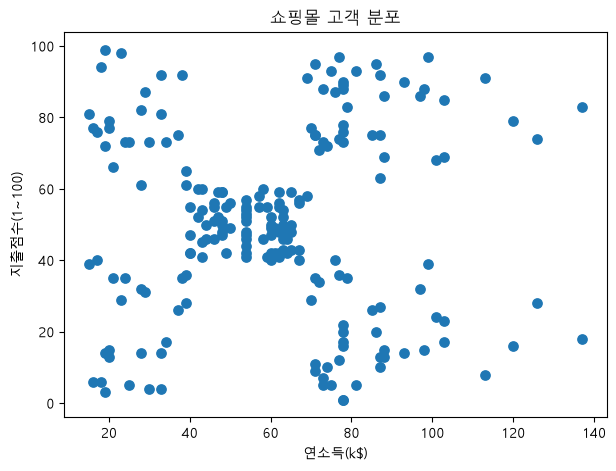

In [10]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family']

# ① read_csv() 안에 경로를 넣기
mall = pd.read_csv('../datasets/unsupervised/Mall_Customers.csv')

plt.figure(figsize=(7, 5))

plt.scatter(mall['Annual Income'], mall['Spending Score'], s=45)

plt.xlabel('연소득(k$)')
plt.ylabel('지출점수(1~100)')

plt.title('쇼핑몰 고객 분포')
plt.show()

C:\Users\301-21\anaconda3\envs\bio1\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\301-21\anaconda3\envs\bio1\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\301-21\anaconda3\envs\bio1\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\301-21\anaconda3\envs\bio1\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMe

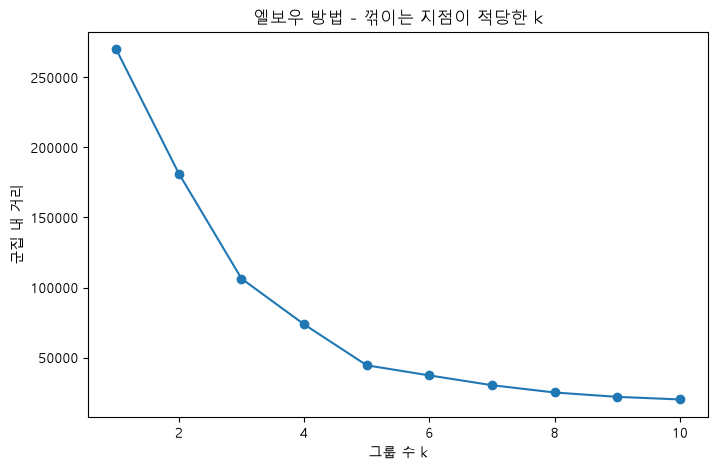

In [17]:
from sklearn.cluster import KMeans
x = mall[['Annual Income', 'Spending Score']]
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(x)
    inertias.append(km.inertia_)  # 각 점과 자기 중심 거리의 제곱합

plt.figure(figsize=(8, 5)); plt.plot(list(k_range), inertias, marker='o')
plt.title('엘보우 방법 - 꺾이는 지점이 적당한 k') ; plt.xlabel('그룹 수 k'); plt.ylabel('군집 내 거리'); plt.show()
#4-5 정도에서 꺾임 : k를 5로 정해 모델링

C:\Users\301-21\anaconda3\envs\bio1\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


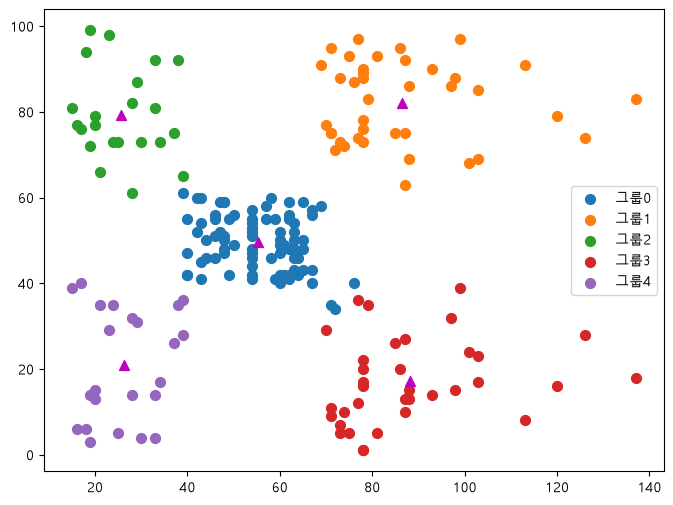

In [30]:
model = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = model.fit_predict(x)
mall['group'] = labels
centers = model.cluster_centers_ #각 군집의 중심점
plt.figure(figsize=(8,6))
for g in range(5):
    pts = mall[mall['group']==g]
    plt.scatter(pts['Annual Income'], pts['Spending Score'], s=50, label=f'그룹{g}')
plt.scatter(centers[:,0], centers[:,1], s=50, c='m',  marker='^')
plt.legend(); plt.show()

In [25]:
new_customer = [[70, 50]] #연소득 70k,지출점수 50
g = model.predict(new_customer)[0]
print(f'새고객 -> 그룹{g}')

새고객 -> 그룹0


C:\Users\301-21\anaconda3\envs\bio1\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [35]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
#데이터 표준화
scaler = StandardScaler()
x_scale = scaler.fit_transform(x)
# eps(엡실론): 한 점을 중심으로 이웃으로 인정하는 반경
# 반경 0.4 안에 자신을 포함해 5개 이상 있으면 핵심점
# 군집에 속하지 못한 점은 잡음(noise) == -1 부여

#DBSCAN 군집화
labels = DBSCAN(eps=0.4, min_samples=5).fit_predict(x_scale)
print(f'DBSCAN 군집 수: {len(set(labels)) - (1 if -1 in labels else 0)}')
print(f'이상치 수: {int((labels == -1).sum())}')

DBSCAN 군집 수: 4
이상치 수: 15
